In [107]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [108]:
df=pd.read_csv('adm_data.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


<Axes: >

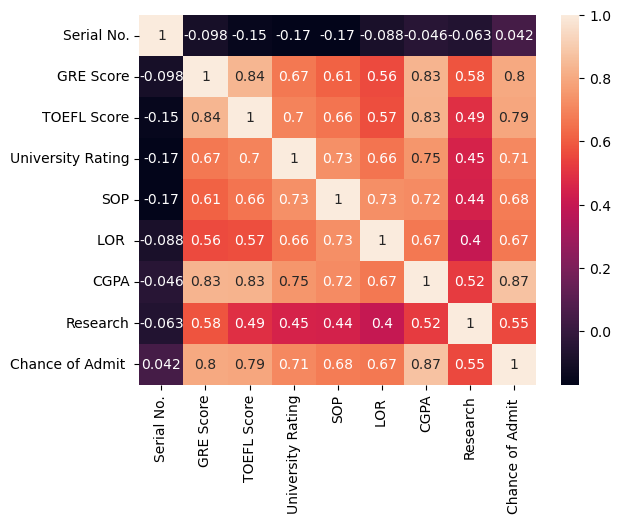

In [109]:
sns.heatmap(df.corr(),annot=True)

In [110]:
df=df.iloc[:,1:]

In [111]:
df.isnull().sum().sum()

0

In [112]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [113]:
x=df.drop(columns=['Chance of Admit '])
y=df['Chance of Admit ']

from sklearn.preprocessing import MinMaxScalar

In [115]:

from sklearn.preprocessing import MinMaxScaler

In [116]:
mi= MinMaxScaler()
x_scaled=mi.fit_transform(x)
x_scaled

array([[0.94      , 0.92857143, 0.75      , ..., 0.875     , 0.91346154,
        1.        ],
       [0.68      , 0.53571429, 0.75      , ..., 0.875     , 0.66346154,
        1.        ],
       [0.52      , 0.42857143, 0.5       , ..., 0.625     , 0.38461538,
        1.        ],
       ...,
       [0.8       , 0.85714286, 0.75      , ..., 0.875     , 0.84935897,
        1.        ],
       [0.44      , 0.39285714, 0.5       , ..., 0.75      , 0.63461538,
        0.        ],
       [0.86      , 0.89285714, 0.75      , ..., 0.75      , 0.91666667,
        1.        ]])

In [117]:
from sklearn.model_selection import train_test_split

In [118]:
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=2)

In [119]:
x_train.shape

(320, 7)

In [120]:
from tensorflow import keras 
from keras import Sequential 
from keras.layers import Dense

In [121]:
model=Sequential()
model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(7,activation='relu'))
model.add(Dense(7,activation='linear'))

C:\Users\thaku\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 7)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 7)                   │              56 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 168 (672.00 B)

 Trainable params: 168 (672.00 B)

 Non-trainable params: 0 (0.00 B)

In [123]:
model.compile(loss='mean_squared_error',optimizer='Adam')

In [124]:
model.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.7263 - val_loss: 0.6800
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6496 - val_loss: 0.6080
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5957 - val_loss: 0.5449
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4956 - val_loss: 0.4885
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4639 - val_loss: 0.4363
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4208 - val_loss: 0.3882
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3712 - val_loss: 0.3430
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3407 - val_loss: 0.2996
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2872 - val_loss: 0.2562
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2436 - val_loss: 0.2084
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1941 - val_loss: 0.1532
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1395 - val_lo

In [125]:
y_pred_test=model.predict(x_test)
y_pred_train=model.predict(x_train)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [126]:
from sklearn.metrics import r2_score

ValueError: y_true and y_pred have different number of output (1!=7)

In [128]:
y_pred_test

array([[0.5663957 , 0.5547616 , 0.58171797, 0.54385346, 0.54126406,
        0.5545471 , 0.51400423],
       [0.95306927, 0.94466376, 1.1185291 , 0.9541483 , 0.9693318 ,
        1.0035974 , 0.9076712 ],
       [0.55104196, 0.57994324, 0.5002165 , 0.5631987 , 0.52853847,
        0.54044527, 0.5442789 ],
       [0.6366378 , 0.6581939 , 0.63829255, 0.6503426 , 0.6265998 ,
        0.6463476 , 0.6188417 ],
       [0.7654343 , 0.76058847, 0.8363974 , 0.77009296, 0.80275935,
        0.7831897 , 0.7837457 ],
       [0.98615205, 0.97202766, 1.043084  , 0.97880244, 0.9977664 ,
        1.0015543 , 0.9893111 ],
       [0.669357  , 0.6862409 , 0.6954731 , 0.6997278 , 0.7321624 ,
        0.6918337 , 0.73646414],
       [0.9076833 , 0.9030475 , 0.8033173 , 0.8897519 , 0.86567485,
        0.86723286, 0.9172209 ],
       [0.5960254 , 0.6091518 , 0.68215907, 0.6181731 , 0.63860327,
        0.63285255, 0.5996823 ],
       [0.6963554 , 0.7724823 , 0.5597596 , 0.78855693, 0.70183885,
        0.7148197 , 0.7

In [130]:
print(y_train.shape,y_pred_train.shape)

(320,) (320, 7)


In [138]:
r2_score(y_train,y_pred_train)

ValueError: y_true and y_pred have different number of output (1!=7)

In [136]:
y_pred_train.shape

(320, 7)

In [140]:
print(x_test.shape,x_train.shape)

(80, 7) (320, 7)
